## 10.8 从梯度提升算法到XGBoost ☆

## 10.8.2.3 XGBoost在Python中的实现

In [1]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataFile = '/Users/lirenyuan/Desktop/maitian/course/data/breast_cancer_m.csv'
data = pd.read_csv(dataFile)
X = data.iloc[: ,0:-1]
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 21)

In [3]:
clf_XGB = XGBClassifier(use_label_encoder=False)
clf_XGB.fit(X_train, y_train)
score = clf_XGB.score(X_test, y_test)
score

[22:51:04] WARNING: /Users/travis/build/dmlc/xgboost/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/opt/anaconda3/lib/python3.8/site-packages/xgboost/sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


0.9649122807017544

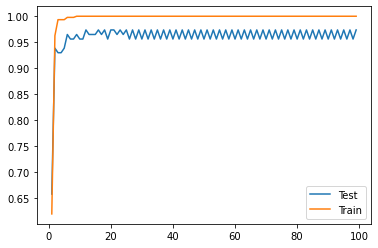

0.9736842105263158 12


In [4]:
scoreTrainList, scoreTestList = [], []
maxTreeNum = 100
for i in range(1,maxTreeNum):
    clf_XGB = XGBClassifier( random_state = 21
                           , n_estimators = i
                           , objective='binary:hinge'
                            ,use_label_encoder=False
                                   )
    clf_XGB.fit(X_train, y_train)
    score_test = clf_XGB.score(X_test, y_test)
    score_train = clf_XGB.score(X_train,y_train)
    scoreTestList.append(score_test)
    scoreTrainList.append(score_train)
plt.plot(range(1,maxTreeNum), scoreTestList, label = 'Test')
plt.plot(range(1,maxTreeNum), scoreTrainList, label = 'Train')
plt.legend()
plt.show()
print(max(scoreTestList),scoreTestList.index(max(scoreTestList))+1)